# Test Saved Model
This notebook loads the test dataset and the saved model (`unet_dr_model.h5`), and tests the images to produce evaluation metrics like accuracy and a confusion matrix.

In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [12]:
# Define dataset path
DATASET_PATH = "Major porject dataset"
test_dir = os.path.join(DATASET_PATH, "test")

IMAGE_SIZE = 224
BATCH_SIZE = 16

# Load test dataset
val_test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes found:", test_generator.class_indices)

Found 231 images belonging to 2 classes.
Classes found: {'DR': 0, 'No_DR': 1}


In [13]:
# Load model
MODEL_PATH = "unet_dr_model.h5"

if os.path.exists(MODEL_PATH):
    print(f"Loading model from {MODEL_PATH}...")
    model = tf.keras.models.load_model(MODEL_PATH)
    model.summary()
else:
    print(f"Model file {MODEL_PATH} not found!")

Loading model from unet_dr_model.h5...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             

 Total params: 4,758,980 (18.15 MB)

 Trainable params: 4,755,138 (18.14 MB)

 Non-trainable params: 3,840 (15.00 KB)

 Optimizer params: 2 (12.00 B)

In [14]:
# Evaluate model on test data
if 'model' in locals():
    print("Evaluating model on test data...")
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
else:
    print("Model was not loaded. Cannot evaluate.")

Evaluating model on test data...
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9177 - loss: 0.2741
Test Accuracy: 91.77%
Test Loss: 0.2741


In [15]:
# Predictions and Classification Report
if 'model' in locals():
    true_labels = test_generator.classes
    predictions = model.predict(test_generator)
    predicted_labels = np.argmax(predictions, axis=1)

    class_names = list(test_generator.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
else:
    print("Model was not loaded. Cannot generate report.")

15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

Classification Report:
              precision    recall  f1-score   support

          DR       0.94      0.89      0.91       113
       No_DR       0.90      0.94      0.92       118

    accuracy                           0.92       231
   macro avg       0.92      0.92      0.92       231
weighted avg       0.92      0.92      0.92       231



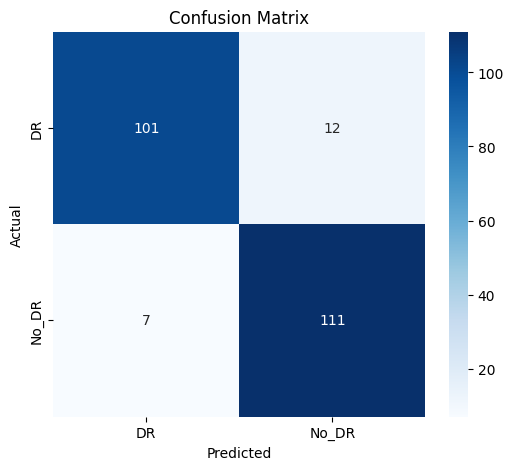

In [16]:
# Confusion Matrix
if 'model' in locals():
    cm = confusion_matrix(true_labels, predicted_labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("Model was not loaded. Cannot display confusion matrix.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step


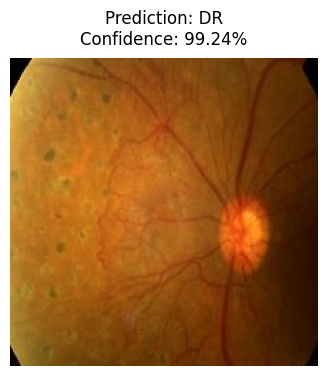

In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def test_single_image(img_path):
    # Load the image and resize it to the expected target size
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    
    # Convert the image to a numpy array
    img_array = image.img_to_array(img)
    
    # Rescale the image (since ImageDataGenerator used rescale=1./255)
    img_array = img_array / 255.0
    
    # Expand dimensions to add the batch size (shape becomes: 1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make the prediction
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    
    # Retrieve the class names from the generator
    class_names = list(test_generator.class_indices.keys())
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[0][predicted_class_index]
    
    # Display the image alongside its prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence*100:.2f}%", pad=10)
    plt.show()

# Example usage:
img_test_path = r"C:\Users\vivaswanth\OneDrive\Desktop\major-project\Major porject dataset\test\DR\4dd71fc7f22b_png.rf.f8c51fadf8174d7de0823f33acf46ff2.jpg" 

# Calling the function to actually run it
test_single_image(img_test_path)
